In [1]:
import os, glob
import xesmf  as xe
import xarray as xr
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path   as mpath
import cartopy.feature   as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy import config
import cartopy.crs     as ccrs
import cartopy.feature as cft
from cartopy.util import add_cyclic_point
import cmocean as cm
import metpy.calc as mpc
import pygmt

In [6]:
# ref: https://scitools.org.uk/cartopy/docs/latest/gallery/lines_and_polygons/always_circular_stereo.html#sphx-glr-gallery-lines-and-polygons-always-circular-stereo-py
def add_circle_boundary(ax):
    # Compute a circle in axes coordinates, which we can use as a boundary
    # for the map. We can pan/zoom as much as we like - the boundary will be
    # permanently circular.
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

In [55]:
def simple_map(lon, lat, dat, cmap=None, tit_str=None, F_save=None, vmin=None, vmax=None):
    if vmax<vmin:
        levels = np.linspace(vmax, vmin, 20)
    else:
        levels = np.linspace(vmin, vmax, 20)
    #fig, axs = plt.subplots(nrows=1,ncols=2,
    #                        subplot_kw={'projection': ccrs.Stereographic()},
    #                        figsize=(8,12))
    #data,lons=add_cyclic_point(dat,coord=lon[0,:])
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    #axs=axs.flatten()
    # fig        = plt.figure(figsize=(12,10))
    # ax1        = fig.add_subplot(2,1,1, projection=ccrs.SouthPolarStereo())
    # ax2        = fig.add_subplot(1,2,2, projection=ccrs.NorthPolarStereo())
    # ax1.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
    # ax2.set_extent([-180, 180,  50,  90], crs=ccrs.PlateCarree())
    #cfs = axs[1].contourf(lons, lat[:,0], data, levels=levels, transform=ccrs.SouthPolarStereo(), cmap=cmap, transform_first=False)
    #cfn = ax2.contourf(lon, lat, dat, levels=levels, transform=ccrs.PlateCarree(), cmap=cmap, transform_first=False)
    #add_circle_boundary(axs[1])
    #add_circle_boundary(ax2)
    #axs[1].add_feature(cfeature.LAND, color='grey')
    #ax2.add_feature(cfeature.LAND, color='grey')
    #axs[1].coastlines(lw=1, resolution='10m')
    #ax2.coastlines(lw=1, resolution='10m')
    #axs[1].gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    #ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    #fig.suptitle(tit_str, fontsize=16)
    #divider = make_axes_locatable(ax2)
    #ax_cb = divider.new_horizontal(size="5%", pad=0.1, axes_class=plt.Axes)
    #fig.add_axes(ax_cb)
    #fig.colorbar(cfs, cax=ax_cb, ticklocation='auto')
    #plt.savefig(F_save)
    #plt.show()
    #plt.close()

In [2]:
D_save     = "/g/data/jk72/da1339/GRAPHICAL/IC/"
G_CICE_0p1 = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p1/linked_files/grid.nc")
iced       = xr.open_dataset("/g/data/jk72/da1339/afim_input/initial_conditions/AOM2_0p1_1997/iced.1997-10-01-00000.nc",decode_times=False)
TLON       = G_CICE_0p1.tlon.values*180/np.pi
TLAT       = G_CICE_0p1.tlat.values*180/np.pi
ULON       = G_CICE_0p1.ulon.values*180/np.pi
ULAT       = G_CICE_0p1.ulat.values*180/np.pi
iced

0.3.0


<xarray.Dataset>
Dimensions:       (nj: 2700, ni: 3600, ncat: 5)
Dimensions without coordinates: nj, ni, ncat
Data variables: (12/35)
    uvel          (nj, ni) float64 ...
    vvel          (nj, ni) float64 ...
    scale_factor  (nj, ni) float64 ...
    swvdr         (nj, ni) float64 ...
    swvdf         (nj, ni) float64 ...
    swidr         (nj, ni) float64 ...
    ...            ...
    qice002       (ncat, nj, ni) float64 ...
    sice003       (ncat, nj, ni) float64 ...
    qice003       (ncat, nj, ni) float64 ...
    sice004       (ncat, nj, ni) float64 ...
    qice004       (ncat, nj, ni) float64 ...
    qsno001       (ncat, nj, ni) float64 ...
Attributes:
    istep1:     2243920
    time:       1254355200.0
    time_forc:  0.0
    nyr:        40
    month:      10
    mday:       1
    sec:        0

<xarray.DataArray (y: 2700, x: 3600)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    lon      (y, x) float64 279.9 279.8 279.7 279.6 ... 80.0 80.0 80.0 80.0
    lat      (y, x) float64 -81.09 -81.09 -81.09 -81.09 ... 65.08 65.04 64.99
Dimensions without coordinates: y, x
min: <xarray.DataArray ()>
array(0.)
max: <xarray.DataArray ()>
array(1.59320265)


makecpt [WARNING]: cmocean/speed is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.
grdimage [WARNING]: Your grid y's or latitudes appear to be outside the map region and will be skipped.
grdimage [WARNING]: No grid or image inside plot domain


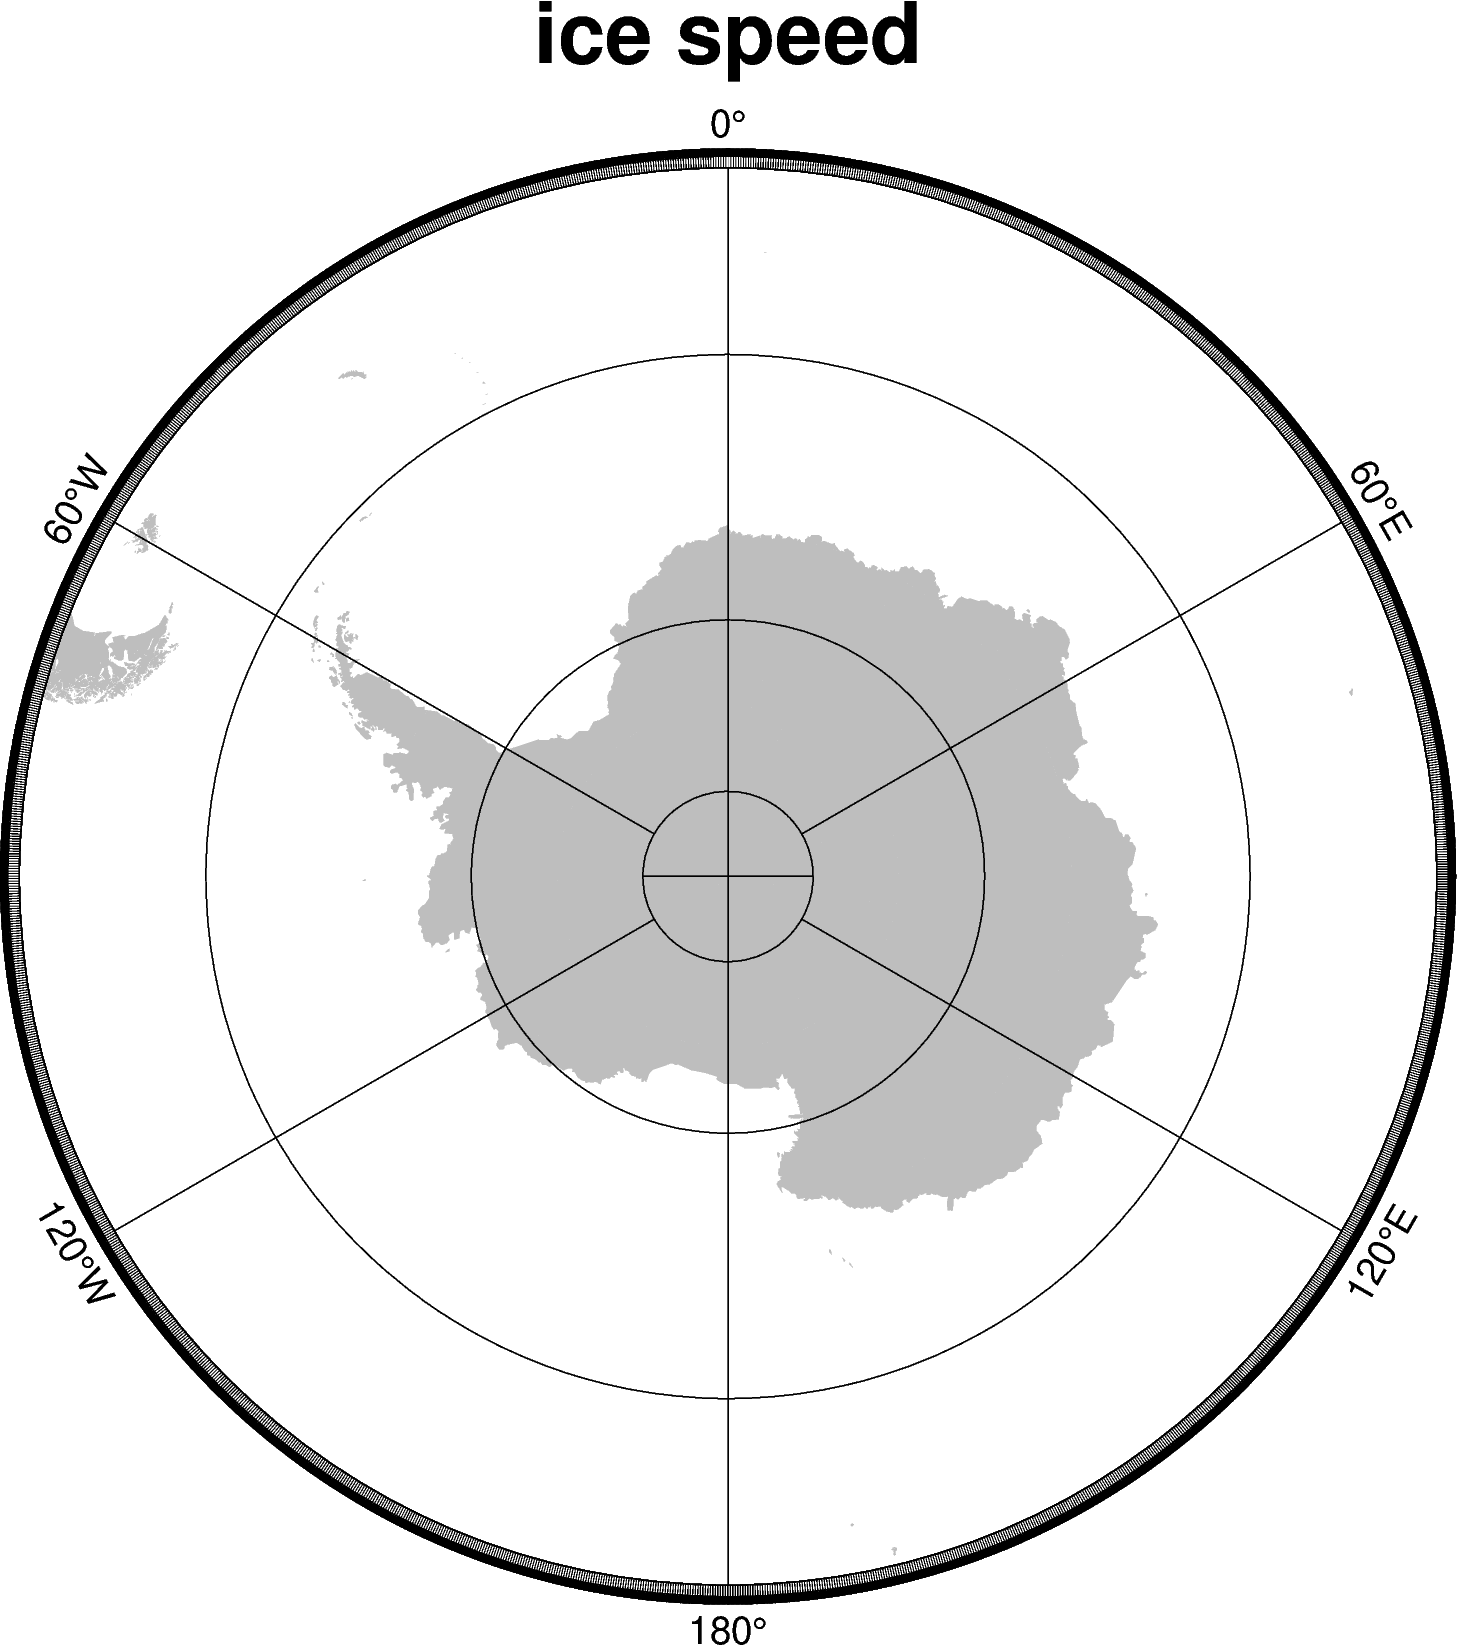

In [81]:
spd        = np.sqrt( iced.uvel.values**2 + iced.vvel.values**2 )
spd[spd>5] = -1e20
P_save     = os.path.join(D_save,"0p1","19971001_ice_speed.png")
da         = xr.DataArray(data=spd, dims=["y", "x"], coords=dict(lon=(["y","x"], np.abs(ULON)), lat=(["y","x"], ULAT)))
print(da)
print(f"min: {da.min()}")
print(f"max: {da.max()}")
fig = pygmt.Figure()
pygmt.makecpt(cmap="cmocean/speed", series=[0, 3, .1])
fig.coast(region=[0,360,-90,-50], projection="S0/-90/12c", frame="ag", land="gray")
fig.grdimage( grid=da, projection="S0/-90/12c", frame=["WSrt+tice speed", "xa0.1", "ya0.1"], cmap=True )
fig.show()
#simple_map(ULON, ULAT, spd, cmap=cm.cm.speed, tit_str="ice speed (cm/day), IC AOM2-0p1 1997-10-01", F_save=P_save, vmin=0, vmax=3)

In [3]:
o2i          = xr.open_dataset("/g/data/jk72/da1339/afim_input/initial_conditions/AOM2_0p1_1997/o2i.nc",decode_times=False)
o2i['sst_i'] = o2i.sst_i.where( o2i.sst_i.values>(273.15-1.9) )
o2i['sst_i'] = o2i.sst_i-273.15

In [4]:
reG_method  = "patch"
F_wgt_tgrid = os.path.join("/","g","data","jk72","da1339","grids","weights","map_AOM2_0p1_to_0p25_t_grid_patch_extrap_neareststod.nc")
F_wgt_ugrid = os.path.join("/","g","data","jk72","da1339","grids","weights","map_AOM2_0p1_to_0p25_u_grid_patch_extrap_neareststod.nc")

In [5]:
AOM2_0p1    = xr.open_dataset("/scratch/jk72/da1339/afim_input/AOM2/0p1/daily/AOM2_1990_01.nc")
G_CICE_0p25 = xr.open_dataset("/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/linked_files/grid.nc")

In [6]:
G_AOM2_0p1_t         = xr.Dataset()
G_AOM2_0p1_t['lon']  = AOM2_0p1.xt_ocean[0,:]
G_AOM2_0p1_t['lat']  = AOM2_0p1.yt_ocean[:,0]
G_AOM2_0p25_t        = xr.Dataset()
G_AOM2_0p25_t['lon'] = G_CICE_0p25.tlon[0,:] * 180/np.pi
G_AOM2_0p25_t['lat'] = G_CICE_0p25.tlat[:,0] * 180/np.pi
G_AOM2_0p1_u         = xr.Dataset()
G_AOM2_0p1_u['lon']  = AOM2_0p1.xu_ocean[0,:]
G_AOM2_0p1_u['lat']  = AOM2_0p1.yu_ocean[:,0]
G_AOM2_0p25_u        = xr.Dataset()
G_AOM2_0p25_u['lon'] = G_CICE_0p25.ulon[0,:] * 180/np.pi
G_AOM2_0p25_u['lat'] = G_CICE_0p25.ulat[:,0] * 180/np.pi

In [7]:
reG_t = xe.Regridder(G_AOM2_0p1_t, G_AOM2_0p25_t, reG_method, extrap_method="nearest_s2d", reuse_weights=True, filename=F_wgt_tgrid)

In [8]:
reG_u = xe.Regridder(G_AOM2_0p1_u, G_AOM2_0p25_u, reG_method, extrap_method="nearest_s2d", reuse_weights=True, filename=F_wgt_ugrid)

In [18]:
iced_0p25                 = xr.Dataset()
iced_0p25['uvel']         = (('nj','ni'),reG_u(iced.uvel).values)
iced_0p25['vvel']         = (('nj','ni'),reG_u(iced.vvel).values)
iced_0p25['scale_factor'] = (('nj','ni'),reG_t(iced.scale_factor).values)
iced_0p25['swvdr']        = (('nj','ni'),reG_t(iced.swvdr).values)
iced_0p25['swvdf']        = (('nj','ni'),reG_t(iced.swvdf).values)
iced_0p25['swidr']        = (('nj','ni'),reG_t(iced.swidr).values)
iced_0p25['swidf']        = (('nj','ni'),reG_t(iced.swidf).values)
iced_0p25['strocnxT']     = (('nj','ni'),reG_t(iced.strocnxT).values)
iced_0p25['strocnyT']     = (('nj','ni'),reG_t(iced.strocnyT).values)
iced_0p25['stressp_1']    = (('nj','ni'),reG_t(iced.stressp_1).values)
iced_0p25['stressp_2']    = (('nj','ni'),reG_t(iced.stressp_2).values)
iced_0p25['stressp_3']    = (('nj','ni'),reG_t(iced.stressp_3).values)
iced_0p25['stressp_4']    = (('nj','ni'),reG_t(iced.stressp_4).values)
iced_0p25['stressm_1']    = (('nj','ni'),reG_t(iced.stressm_1).values)
iced_0p25['stressm_2']    = (('nj','ni'),reG_t(iced.stressm_2).values)
iced_0p25['stressm_3']    = (('nj','ni'),reG_t(iced.stressm_3).values)
iced_0p25['stressm_4']    = (('nj','ni'),reG_t(iced.stressm_4).values)
iced_0p25['stress12_1']   = (('nj','ni'),reG_t(iced.stress12_1).values)
iced_0p25['stress12_2']   = (('nj','ni'),reG_t(iced.stress12_2).values)
iced_0p25['stress12_3']   = (('nj','ni'),reG_t(iced.stress12_3).values)
iced_0p25['stress12_4']   = (('nj','ni'),reG_t(iced.stress12_4).values)
iced_0p25['iceumask']     = (('nj','ni'),reG_u(iced.iceumask).values)
iced_0p25['aicen']        = (('ncat','nj','ni'),reG_t(iced.aicen).values)
iced_0p25['vicen']        = (('ncat','nj','ni'),reG_t(iced.vicen).values)
iced_0p25['vsnon']        = (('ncat','nj','ni'),reG_t(iced.vsnon).values)
iced_0p25['Tsfcn']        = (('ncat','nj','ni'),reG_t(iced.Tsfcn).values)
iced_0p25['sice001']      = (('ncat','nj','ni'),reG_t(iced.sice001).values)
iced_0p25['sice002']      = (('ncat','nj','ni'),reG_t(iced.sice002).values)
iced_0p25['sice003']      = (('ncat','nj','ni'),reG_t(iced.sice003).values)
iced_0p25['sice004']      = (('ncat','nj','ni'),reG_t(iced.sice004).values)
iced_0p25['qice001']      = (('ncat','nj','ni'),reG_t(iced.qice001).values)
iced_0p25['qice002']      = (('ncat','nj','ni'),reG_t(iced.qice002).values)
iced_0p25['qice003']      = (('ncat','nj','ni'),reG_t(iced.qice003).values)
iced_0p25['qice004']      = (('ncat','nj','ni'),reG_t(iced.qice004).values)
iced_0p25['qsno001']      = (('ncat','nj','ni'),reG_t(iced.qsno001).values)
iced_0p25['sst']          = (('nj','ni'),reG_t(o2i.sst_i.isel(time=0)).values)
iced_0p25['sss']          = (('nj','ni'),reG_t(o2i.sss_i.isel(time=0)).values)
iced_0p25['uocn']         = (('nj','ni'),reG_u(o2i.ssu_i.isel(time=0)).values)
iced_0p25['vocn']         = (('nj','ni'),reG_u(o2i.ssv_i.isel(time=0)).values)
iced_0p25['ss_tltx']      = (('nj','ni'),reG_u(o2i.sslx_i.isel(time=0)).values)
iced_0p25['ss_tlty']      = (('nj','ni'),reG_u(o2i.ssly_i.isel(time=0)).values)
iced_0p25['frzmlt']       = (('nj','ni'),reG_t(o2i.pfmice_i.isel(time=0)).values)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xesmf/frontend.py:696: UserWarning: Using dimensions ('ny', 'nx') from data variable sst_i as the horizontal dimensions for the regridding.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xesmf/frontend.py:696: UserWarning: Using dimensions ('ny', 'nx') from data variable sss_i as the horizontal dimensions for the regridding.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xesmf/frontend.py:696: UserWarning: Using dimensions ('ny', 'nx') from data variable ssu_i as the horizontal dimensions for the regridding.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xesmf/frontend.py:696: UserWarning: Using dimensions ('ny', 'nx') from data variable ssv_i as the horizontal dimensions for the regridding.
  warnings.warn(
/g/data/hh5/public/apps/minicond

In [24]:
iced_0p25['uvel'] = iced_0p25.uvel.where( np.abs(iced_0p25.uvel)<5, 0 )
iced_0p25['vvel'] = iced_0p25.vvel.where( np.abs(iced_0p25.vvel)<5, 0 )

In [32]:
iced_0p25['scale_factor'] = iced_0p25.scale_factor.where( np.abs(iced_0p25.scale_factor)<2e3, 0 )

In [117]:
iced_0p25['swvdr']      = iced_0p25.swvdr.where( np.abs(iced_0p25.swvdr)<1e3, 0 )
iced_0p25['swvdf']      = iced_0p25.swvdf.where( np.abs(iced_0p25.swvdf)<1e3, 0 )
iced_0p25['swidr']      = iced_0p25.swidr.where( np.abs(iced_0p25.swidr)<1e3, 0 )
iced_0p25['swidf']      = iced_0p25.swidf.where( np.abs(iced_0p25.swidf)<1e3, 0 )
iced_0p25['strocnxT']   = iced_0p25.strocnxT.where( np.abs(iced_0p25.strocnxT)<10, 0 )
iced_0p25['strocnyT']   = iced_0p25.strocnyT.where( np.abs(iced_0p25.strocnyT)<10, 0 )
iced_0p25['stressp_1']  = iced_0p25.stressp_1.where( np.abs(iced_0p25.stressp_1)<1e5, 0 )
iced_0p25['stressp_2']  = iced_0p25.stressp_2.where( np.abs(iced_0p25.stressp_2)<1e5, 0 )
iced_0p25['stressp_3']  = iced_0p25.stressp_3.where( np.abs(iced_0p25.stressp_3)<1e5, 0 )
iced_0p25['stressp_4']  = iced_0p25.stressp_4.where( np.abs(iced_0p25.stressp_4)<1e5, 0 )
iced_0p25['stressm_1']  = iced_0p25.stressm_1.where( np.abs(iced_0p25.stressm_1)<1e5, 0 )
iced_0p25['stressm_2']  = iced_0p25.stressm_2.where( np.abs(iced_0p25.stressm_2)<1e5, 0 )
iced_0p25['stressm_3']  = iced_0p25.stressm_3.where( np.abs(iced_0p25.stressm_3)<1e5, 0 )
iced_0p25['stressm_4']  = iced_0p25.stressm_4.where( np.abs(iced_0p25.stressm_4)<1e5, 0 )
iced_0p25['stress12_1'] = iced_0p25.stress12_1.where( np.abs(iced_0p25.stress12_1)<1e5, 0 )
iced_0p25['stress12_2'] = iced_0p25.stress12_2.where( np.abs(iced_0p25.stress12_2)<1e5, 0 )
iced_0p25['stress12_3'] = iced_0p25.stress12_3.where( np.abs(iced_0p25.stress12_3)<1e5, 0 )
iced_0p25['stress12_4'] = iced_0p25.stress12_4.where( np.abs(iced_0p25.stress12_4)<1e5, 0 )
iced_0p25['iceumask']   = iced_0p25.iceumask.where( np.abs(iced_0p25.iceumask)<2, 0 )
iced_0p25['aicen']      = iced_0p25.aicen.where( np.abs(iced_0p25.aicen)<1, 0 )
iced_0p25['vicen']      = iced_0p25.vicen.where( np.abs(iced_0p25.vicen)<1, 0 )
iced_0p25['vsnon']      = iced_0p25.vsnon.where( np.abs(iced_0p25.vsnon)<1, 0 )
iced_0p25['Tsfcn']      = iced_0p25.Tsfcn.where( np.abs(iced_0p25.Tsfcn)<40, 0 )
iced_0p25['sice001']    = iced_0p25.sice001.where( np.abs(iced_0p25.sice001)<60, 0 )
iced_0p25['sice002']    = iced_0p25.sice002.where( np.abs(iced_0p25.sice002)<60, 0 )
iced_0p25['sice003']    = iced_0p25.sice003.where( np.abs(iced_0p25.sice003)<60, 0 )
iced_0p25['sice004']    = iced_0p25.sice004.where( np.abs(iced_0p25.sice004)<60, 0 )
iced_0p25['qice001']    = iced_0p25.qice001.where( np.abs(iced_0p25.qice001)<1, 0 )
iced_0p25['qice002']    = iced_0p25.qice002.where( np.abs(iced_0p25.qice002)<1, 0 )
iced_0p25['qice003']    = iced_0p25.qice003.where( np.abs(iced_0p25.qice003)<1, 0 )
iced_0p25['qice004']    = iced_0p25.qice004.where( np.abs(iced_0p25.qice004)<1, 0 )
iced_0p25['sst']        = iced_0p25.sst.where( iced_0p25.sst!=np.nan, -1.8)
iced_0p25['sss']        = iced_0p25.sss.where( np.abs(iced_0p25.sss)<60, 0)
iced_0p25['uocn']       = iced_0p25.uocn.where( np.abs(iced_0p25.uocn)<5, 0)
iced_0p25['vocn']       = iced_0p25.vocn.where( np.abs(iced_0p25.vocn)<5, 0)
iced_0p25['ss_tltx']    = iced_0p25.ss_tltx.where( np.abs(iced_0p25.ss_tltx)<1e-2, 0)
iced_0p25['ss_tlty']    = iced_0p25.ss_tlty.where( np.abs(iced_0p25.ss_tlty)<1e-2, 0)
iced_0p25['frzmlt']     = iced_0p25.frzmlt.where( np.abs(iced_0p25.frzmlt)<40, 0)

In [118]:
iced_0p25 = iced_0p25.assign_attrs( {'istep1' : 2243920, 'time' : 1254355200.0, 'time_forc' : 0.0, 'nyr' : 40, 'month' : 10, 'mday' : 1, 'sec' : 0 } )
iced_0p25.to_netcdf("/g/data/jk72/da1339/afim_input/initial_conditions/iced.1997-10-01.0p25.reG_fm_AOM2-01_with_o2i.nc", encoding=encoding, mode='w')

In [ ]:
idx = 13
for year in range(1993, 2019):
    F_out = f"/home/581/da1339/DATA/ocn/AOM2/ERA5/ocean/0p25/daily/{year}_ocean_daily.nc"
    for var in ['area_t', 'area_u', 'mld', 'surface_pot_temp', 'surface_salt', 'usurf', 'vsurf']:
        if var in ['area_t', 'area_u']:
            F_in = f"/g/data/ik11/outputs/access-om2-025/025deg_era5_iaf/output{idx:03}/ocean/ocean-2d-{var}.nc"
        else:
            F_in = f"/g/data/ik11/outputs/access-om2-025/025deg_era5_iaf/output{idx:03}/ocean/ocean-2d-{var}-1-daily-mean-ym_{year:04}_01.nc"
            F_tmp = "/home/581/da1339/DATA/ocn/AOM2/ERA5/ocean/0p25/daily/tmp.nc"
            cmd_att = f"ncatted -O -a _FillValue,time_bnds,d,, {F_in} {F_tmp}"
            try:
                subprocess.run(cmd_att, shell=True, check=True)
            except subprocess.CalledProcessError as e:
                print(f"Error removing attribute from {F_in}: {e}")
                continue
            F_in = F_tmp
        # Check if the input file exists
        if not os.path.exists(F_in):
            print(f"Error: File not found: {F_in}")
            continue
        # Append variable to the output file
        cmd_app = f"ncks -A -v {var} {F_in} {F_out}"
        try:
            subprocess.run(cmd_app, shell=True, check=True)
            print(f"Appended {var} from {F_in} to {F_out}")
        except subprocess.CalledProcessError as e:
            print(f"Error: Command '{cmd_app}' failed with error code {e.returncode}")
        # Remove temporary file after use
        if var not in ['area_t', 'area_u']:
            os.remove(F_tmp)
    idx += 1

In [ ]:
D_in  = "/g/data/ik11/outputs/access-om2-025/025deg_era5_iaf"
D_out = "/home/581/da1339/DATA/ocn/AOM2/ERA5/ocean/0p25/monthly"
idx = 21
for year in range(2001, 2019):
    F_out = f"{D_out}/{year}_ocean_daily.nc"
    for var in ['area_t', 'area_u', 'mld', 'temp', 'salt', 'u', 'v']:
        if var in ['area_t', 'area_u']:
            F_in = f"{D_in}/output{idx:03}/ocean/ocean-2d-{var}.nc"
        elif var=='mld':
            F_in = f"{D_in}/output{idx:03}/ocean/ocean-2d-{var}-1-monthly-mean-ym_{year:04}_01.nc"
            F_tmp = f"{D_out}/tmp.nc"
            cmd_att = f"ncatted -O -a _FillValue,time_bnds,d,, {F_in} {F_tmp}"
            try:
                subprocess.run(cmd_att, shell=True, check=True)
            except subprocess.CalledProcessError as e:
                print(f"Error removing attribute from {F_in}: {e}")
                continue
            F_in = F_tmp
        else:
            F_in = f"{D_in}/output{idx:03}/ocean/ocean-3d-{var}-1-monthly-mean-ym_{year:04}_01.nc"
            F_tmp1 = f"{D_out}/tmp.nc"
            cmd_att = f"ncatted -O -a _FillValue,time_bnds,d,, {F_in} {F_tmp}"
            try:
                subprocess.run(cmd_att, shell=True, check=True)
            except subprocess.CalledProcessError as e:
                print(f"Error removing attribute from {F_in}: {e}")
                continue
            F_tmp2 = f"{D_out}/tmp2.nc"
            cmd_hyp = f"ncks -O -v {var} -d st_ocean,0,0 {F_tmp1} {F_tmp2}"
            try:
                subprocess.run(cmd_hyp, shell=True, check=True)
            except subprocess.CalledProcessError as e:
                print(f"Error trying to hyperslab: {e}")
                continue
            cmd_squ = f"ncwa -O -a st_ocean {F_tmp2} {F_tmp2}"
            try:
                subprocess.run(cmd_squ, shell=True, check=True)
            except subprocess.CalledProcessError as e:
                print(f"Error trying to squeez: {e}")
                continue
            F_in = F_tmp2
        # Check if the input file exists
        if not os.path.exists(F_in):
            print(f"Error: File not found: {F_in}")
            continue
        # Append variable to the output file
        cmd_app = f"ncks -A -v {var} {F_in} {F_out}"
        try:
            subprocess.run(cmd_app, shell=True, check=True)
            print(f"Appended {var} from {F_in} to {F_out}")
        except subprocess.CalledProcessError as e:
            print(f"Error: Command '{cmd_app}' failed with error code {e.returncode}")
        # Remove temporary file after use
        if var not in ['area_t', 'area_u']:
            os.remove(F_tmp)
    idx += 1